In [1]:
from google.colab import drive

# Mount Google Drive so Colab can access files stored in MyDrive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Copy the images folder from Google Drive into the Colab working directory
# for easier access when training
!cp -r /content/drive/MyDrive/images /content/images

In [3]:
!pip install pandas

import pandas as pd
import os
import numpy as np

# used for plotting images and the confusion matrix
import matplotlib.pyplot as plt

# used to make the confusion matrix heatmap display neater
import seaborn as sns

import torch

import torch.nn as nn

from torch.utils.data import DataLoader

from torchvision import datasets, transforms

In [4]:
# Training and testing image folder locations
train_data_dir = "/content/images/TRAIN"
test_data_dir = "/content/images/TEST"

In [5]:
# Check if the training data directory exists before trying to use it
if os.path.exists(train_data_dir):
    print("Train folder exists")
    print("Training class folders:", os.listdir(train_data_dir))
else:
    raise FileNotFoundError(
        f"Training folder not found at path: {train_data_dir}"
    )

Train folder exists
Training class folders: ['MONOCYTE', 'EOSINOPHIL', 'NEUTROPHIL', 'LYMPHOCYTE']


In [6]:
# Each image will go through these preprocessing steps before entering the model
transform = transforms.Compose([
    # Resize every image so the CNN receives the same input size
    transforms.Resize((128, 128)),

    # Convert the image into a PyTorch tensor
    # This changes pixel values from [0, 255] to [0, 1]
    transforms.ToTensor(),

    # Normalize each RGB channel
    # This shifts values roughly into the range [-1, 1]
    # Normalization helps training become more stable
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [7]:
# ImageFolder reads images from folders and assigns labels automatically
# Each subfolder name represents a class label (cell type), e.g.:
# EOSINOPHIL, LYMPHOCYTE, MONOCYTE, NEUTROPHIL
train_dataset = datasets.ImageFolder(train_data_dir, transform=transform)
test_dataset = datasets.ImageFolder(test_data_dir, transform=transform)

# Show class names and dataset sizes
print("Classes:", train_dataset.classes)
print("Number of training images:", len(train_dataset))
print("Number of testing images:", len(test_dataset))

Classes: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
Number of training images: 9957
Number of testing images: 2487


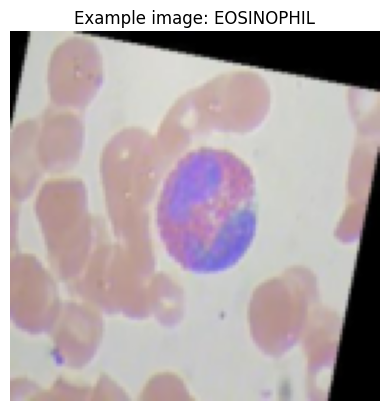

In [8]:

# Get one image-label pair from the training set
image, label = train_dataset[0]

# Undo normalization so the image looks normal when displayed
display_image = image.clone()
display_image = display_image * 0.5 + 0.5

# Change tensor shape from [C, H, W] to [H, W, C] for matplotlib formatting
display_image = display_image.permute(1, 2, 0)

# Plot the image
plt.imshow(display_image)
plt.title(f"Example image: {train_dataset.classes[label]}")
plt.axis("off")
plt.show()

In [9]:
# DataLoader breaks the dataset into mini-batches
# this model sees 32 images at a time
# shuffle=True for training so the model does not see
# images in the exact same order every epoch
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# For testing, shuffle=True for mixed output order
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Train size: 9957
Test size: 2487


In [10]:
# cell image -> look for features -> shrink/organize features -> make prediction

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Input and feature extraction
        # The convolution layers look at the image and learn patterns.
        # Early layers pick up simple things like edges, later layers learn more complex structures.

        self.conv = nn.Sequential(

            # First layer: basic features like edges and color changes
            # Input: 3 channels (RGB)
            # Output: 32 feature maps
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            # Downsample the image (128 → 64)
            nn.MaxPool2d(2),

            # Second layer: builds on earlier features (textures, shapes)
            # Input: 32 feature maps
            # Output: 64 feature maps
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 64 → 32

            # Third layer: captures more complex patterns (cell structure)
            # Input: 64 feature maps
            # Output: 128 feature maps
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 32 → 16
        )

        # Classification
        # After extracting features, we flatten them and classify the image into a cell type.

        self.fc = nn.Sequential(

            # Turn feature maps into a single vector
            nn.Flatten(),

            # Fully connected layer learns how to combine features
            # After three pooling layers, 128x128 becomes 16x16
            # So the flattened size is 128 * 16 * 16
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),

            # Helps prevent overfitting
            nn.Dropout(0.3),

            # Final output: 4 cell types
            nn.Linear(256, 4)
        )

    def forward(self, x):
        # Extract features from the image
        x = self.conv(x)

        # Use those features to make a prediction
        x = self.fc(x)

        return x


model = SimpleCNN()
print(model)

SimpleCNN(
  (conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=4, bias=True)
  )
)


In [11]:
# CrossEntropyLoss is standard for multi-class classification
# It compares the model's predictions to the true labels
loss_fn = nn.CrossEntropyLoss()

# Adam updates the model weights using gradients
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [12]:
# Use GPU if available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Move the model to the selected device
model = model.to(device)

Using device: cuda


In [13]:
num_epochs = 20

for epoch in range(num_epochs):
    # Put the model in training mode
    model.train()

    running_loss = 0.0

    # Loop through each training batch
    for images, labels in train_loader:
        # Move batch data to the same device as the model
        images = images.to(device)
        labels = labels.to(device)

        # Clear old gradients from the previous batch
        optimizer.zero_grad()

        # Forward pass: send images through the model
        outputs = model(images)

        # Compute the loss for this batch
        loss = loss_fn(outputs, labels)

        # Backward pass: compute gradients
        loss.backward()

        # Update weights
        optimizer.step()

        # Add this batch's loss to the running total
        running_loss += loss.item()

    # Average loss across all batches in this epoch
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {avg_loss:.4f}")

Epoch 1/20, Loss: 1.1729
Epoch 2/20, Loss: 0.6415
Epoch 3/20, Loss: 0.4082
Epoch 4/20, Loss: 0.2836
Epoch 5/20, Loss: 0.1936
Epoch 6/20, Loss: 0.1657
Epoch 7/20, Loss: 0.1218
Epoch 8/20, Loss: 0.0817
Epoch 9/20, Loss: 0.1030
Epoch 10/20, Loss: 0.0547
Epoch 11/20, Loss: 0.0486
Epoch 12/20, Loss: 0.0332
Epoch 13/20, Loss: 0.0559
Epoch 14/20, Loss: 0.0353
Epoch 15/20, Loss: 0.0574
Epoch 16/20, Loss: 0.0297
Epoch 17/20, Loss: 0.0232
Epoch 18/20, Loss: 0.0460
Epoch 19/20, Loss: 0.0405
Epoch 20/20, Loss: 0.0176


In [14]:
# Put the model in evaluation mode
# This turns off dropout behavior and uses learned weights only
model.eval()

results = []
correct = 0
total = 0

# No gradients are needed during evaluation
with torch.no_grad():
    for images, labels in test_loader:
        # Move images and labels to device
        images = images.to(device)
        labels = labels.to(device)

        # Get prediction scores from the model
        outputs = model(images)

        # Choose the class with the highest score
        _, predicted = torch.max(outputs, 1)

        # Update overall accuracy counts
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # Save each prediction in a list for pandas analysis
        for true_label, pred_label in zip(labels.cpu().numpy(), predicted.cpu().numpy()):
            results.append({
                "true_label": test_dataset.classes[true_label],
                "predicted_label": test_dataset.classes[pred_label],
                "correct": true_label == pred_label
            })

# Compute final overall test accuracy
accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

# Convert the results list into a pandas DataFrame
results_df = pd.DataFrame(results)

print("\n5 random predictions:")
print(results_df.sample(5, random_state=42))

Test Accuracy: 74.43%

5 random predictions:
      true_label predicted_label  correct
1660    MONOCYTE      NEUTROPHIL    False
1547    MONOCYTE      NEUTROPHIL    False
1094    MONOCYTE        MONOCYTE     True
1487  LYMPHOCYTE      LYMPHOCYTE     True
1593    MONOCYTE        MONOCYTE     True


In [15]:
# Group rows by the true class label
# Then compute the average of the "correct" column
# Since True = 1 and False = 0, the mean becomes class accuracy
per_class_accuracy = (
    results_df.groupby("true_label")["correct"]
    .mean()
    .sort_values(ascending=False) * 100
)

print("Per-class accuracy (%):")
print(per_class_accuracy)

Per-class accuracy (%):
true_label
LYMPHOCYTE    88.064516
MONOCYTE      75.483871
NEUTROPHIL    74.038462
EOSINOPHIL    60.192616
Name: correct, dtype: float64


In [16]:
# Crosstab creates a table showing true labels vs predicted labels
confusion_df = pd.crosstab(
    results_df["true_label"],
    results_df["predicted_label"],
    rownames=["True Label"],
    colnames=["Predicted Label"]
)

print(confusion_df)

Predicted Label  EOSINOPHIL  LYMPHOCYTE  MONOCYTE  NEUTROPHIL
True Label                                                   
EOSINOPHIL              375           0         0         248
LYMPHOCYTE               30         546        37           7
MONOCYTE                  0           0       468         152
NEUTROPHIL              138           4        20         462


In [17]:
# Keep only the rows where the model was wrong
mistakes_df = results_df[results_df["correct"] == False]

print("Number of misclassified images:", len(mistakes_df))
print(mistakes_df.head())

# Save mistakes to a CSV file
mistakes_df.to_csv("misclassified_images.csv", index=False)

Number of misclassified images: 636
    true_label predicted_label  correct
6     MONOCYTE      NEUTROPHIL    False
10  EOSINOPHIL      NEUTROPHIL    False
12  EOSINOPHIL      NEUTROPHIL    False
14  LYMPHOCYTE      EOSINOPHIL    False
22  EOSINOPHIL      NEUTROPHIL    False


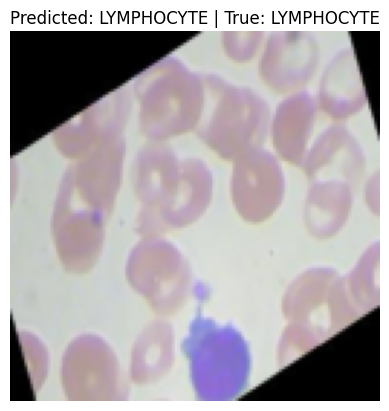

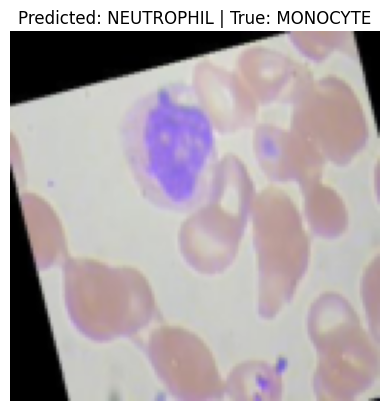

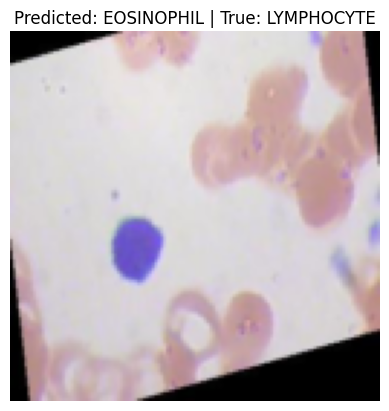

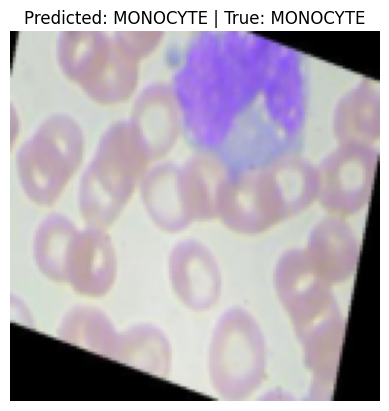

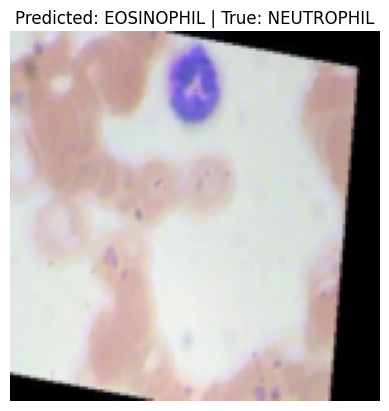

In [18]:
with torch.no_grad():
    # Take one random batch
    images, labels = next(iter(test_loader))

    # Move to device
    images = images.to(device)
    labels = labels.to(device)

    # Get predictions
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

# Move data back to CPU for plotting
images_cpu = images.cpu()
labels_cpu = labels.cpu()
predicted_cpu = predicted.cpu()

# Plot 5 example predictions
for i in range(5):
    img = images_cpu[i].clone()

    # Undo normalization so the image displays correctly
    img = img * 0.5 + 0.5

    # Convert from [C, H, W] to [H, W, C]
    img = img.permute(1, 2, 0)

    plt.figure()
    plt.imshow(img)
    plt.title(
        f"Predicted: {test_dataset.classes[predicted_cpu[i].item()]} | "
        f"True: {test_dataset.classes[labels_cpu[i].item()]}"
    )
    plt.axis("off")
    plt.show()

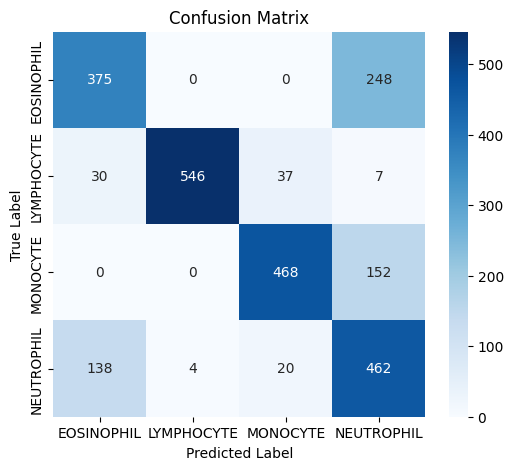

In [19]:
# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_df,
    annot=True,   # show the actual numbers inside each cell
    fmt="d",      # format numbers as integers
    cmap="Blues"  # use a blue color scale (darker = higher values)
)

# Add a title to explain what the plot represents
plt.title("Confusion Matrix")

# Label axes so it's clear what is being compared
plt.xlabel("Predicted Label")   # model predictions
plt.ylabel("True Label")        # actual labels

# Display the plot
plt.show()